In [42]:
# importing the required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import kmapper as km
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [2]:
#importing the dataset
df_final = pd.read_csv("../data/combined_cleaned_TDA.csv")

In [12]:
#spliting into features (X) and target (Y)
Y = df_final['5'] #column named 5 is churn column
X = df_final.drop(columns=['5'])

In [14]:
#train-test split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

------------------------------------------------------------------------------------------------------

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import os
import joblib

In [18]:
#Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=42) #creating the model
log_reg.fit(X_train, Y_train) #training the model (.fit() means learn from the dataset)
y_pred_lr = log_reg.predict(X_test) #make predictions
print("Logistic Regression Accuracy:", accuracy_score(Y_test, y_pred_lr)) #evaluate the model's performance
print(classification_report(Y_test, y_pred_lr)) #metrics report

Logistic Regression Accuracy: 0.9680548982489352
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      2514
         1.0       0.97      0.95      0.96      1712

    accuracy                           0.97      4226
   macro avg       0.97      0.97      0.97      4226
weighted avg       0.97      0.97      0.97      4226



In [19]:
#Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42) #creating the model
rf.fit(X_train, Y_train) #training the model (.fit() means learn from the dataset)
y_pred_rf = rf.predict(X_test) #make predictions
print("Random Forest Accuracy:", accuracy_score(Y_test, y_pred_rf)) #evaluate the model's performance
print(classification_report(Y_test, y_pred_rf)) #metrics report

Random Forest Accuracy: 0.9749171793658306
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      2514
         1.0       0.98      0.95      0.97      1712

    accuracy                           0.97      4226
   macro avg       0.98      0.97      0.97      4226
weighted avg       0.98      0.97      0.97      4226



In [21]:
# XGBoost

xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42) #creating the model
xgb.fit(X_train, Y_train) #training the model (.fit() means learn from the dataset)
y_pred_xgb = xgb.predict(X_test) #make predictions
print("XGBoost Accuracy:", accuracy_score(Y_test, y_pred_xgb)) #evaluate the model's performance
print(classification_report(Y_test, y_pred_xgb)) #metrics report

C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:38:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.971131093232371
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      2514
         1.0       0.98      0.95      0.96      1712

    accuracy                           0.97      4226
   macro avg       0.97      0.97      0.97      4226
weighted avg       0.97      0.97      0.97      4226



In [22]:
#comparing results of various models

results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [accuracy_score(Y_test, y_pred_lr),
        accuracy_score(Y_test, y_pred_rf),
        accuracy_score(Y_test, y_pred_xgb)]})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.968055
1        Random Forest  0.974917
2              XGBoost  0.971131


In [31]:
#downloading train and test data files

save_path = "../data/train_test_data"
os.makedirs(save_path, exist_ok=True)

X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
Y_train_df = pd.DataFrame(Y_train, columns=['churn'])
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)
Y_test_df = pd.DataFrame(Y_test, columns=['churn'])

try:
    X_train_df.to_csv(os.path.join(save_path, "X_train_bal.csv"), index=False)
    Y_train_df.to_csv(os.path.join(save_path, "Y_train_bal.csv"), index=False)
    X_test_df.to_csv(os.path.join(save_path, "X_test.csv"), index=False)
    Y_test_df.to_csv(os.path.join(save_path, "Y_test.csv"), index=False)
    print("SMOTE based train/test sets saved")
except Exception as e:
    print("Could not save", e)

SMOTE based train/test sets saved


In [27]:
print(Y.value_counts())

5
0.0    12568
1.0     8561
Name: count, dtype: int64


In [35]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


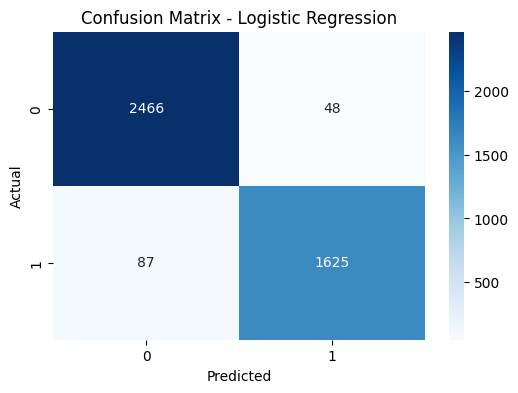

In [37]:
#confusion matrix - Logistic regression

plot_conf_matrix(Y_test, y_pred_lr, "Logistic Regression")


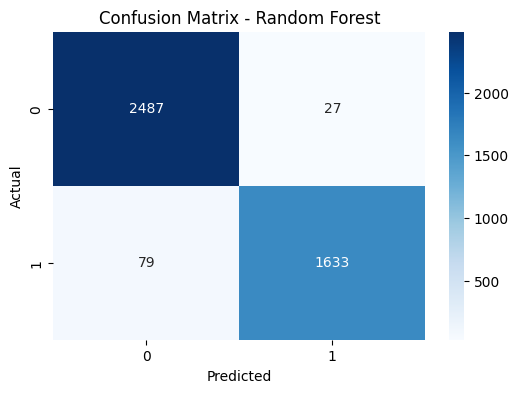

In [39]:
#confusion matrix - Random Forest

plot_conf_matrix(Y_test, y_pred_rf, "Random Forest")


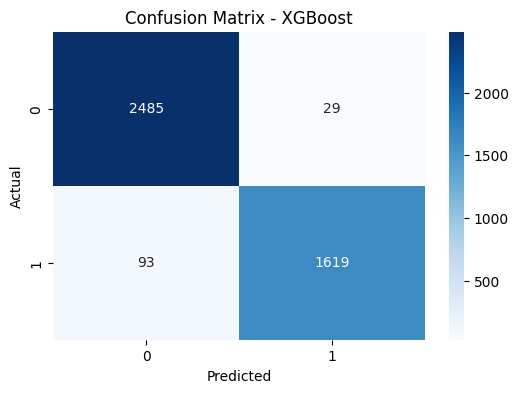

In [41]:
#confusion matrix - XGBoost

plot_conf_matrix(Y_test, y_pred_xgb, "XGBoost")


In [43]:
#testing logistic regression

accuracy = accuracy_score(Y_test, y_pred_lr)
precision = precision_score(Y_test, y_pred_lr)
recall = recall_score(Y_test, y_pred_lr)
f1 = f1_score(Y_test, y_pred_lr)
cm = confusion_matrix(Y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9680548982489352
Precision: 0.9713090257023311
Recall: 0.9491822429906542
F1 Score: 0.9601181683899557
Confusion Matrix:
 [[2466   48]
 [  87 1625]]


In [44]:
#testing Random Forest

accuracy = accuracy_score(Y_test, y_pred_rf)
precision = precision_score(Y_test, y_pred_rf)
recall = recall_score(Y_test, y_pred_rf)
f1 = f1_score(Y_test, y_pred_rf)
cm = confusion_matrix(Y_test, y_pred_rf)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9749171793658306
Precision: 0.9837349397590361
Recall: 0.9538551401869159
F1 Score: 0.968564650059312
Confusion Matrix:
 [[2487   27]
 [  79 1633]]


In [45]:
#testing XGBoost

accuracy = accuracy_score(Y_test, y_pred_xgb)
precision = precision_score(Y_test, y_pred_xgb)
recall = recall_score(Y_test, y_pred_xgb)
f1 = f1_score(Y_test, y_pred_xgb)
cm = confusion_matrix(Y_test, y_pred_xgb)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


Accuracy: 0.971131093232371
Precision: 0.9824029126213593
Recall: 0.945677570093458
F1 Score: 0.9636904761904762
Confusion Matrix:
 [[2485   29]
 [  93 1619]]


In [32]:
# saving the models

save_path = "../data/tested_models"
os.makedirs(save_path, exist_ok=True)

try:
    joblib.dump(rf, os.path.join(save_path, "random_forest_model.pkl"))
    joblib.dump(log_reg, os.path.join(save_path, "logistic_regression_model.pkl"))
    joblib.dump(xgb, os.path.join(save_path, "xgboost_model.pkl"))
    print("Models saved")
except Exception as e:
    print("Models not found or not saved", e)

Models saved


whenever you run the models in other nb's import them first like this:

rf = joblib.load("random_forest_model.pkl")

start new nbs as below:

import pandas as pd
import joblib

X = pd.read_csv("X_final_with_target.csv") #this is the dataset after doing tda
rf = joblib.load("random_forest_model.pkl")

y_pred = rf.predict(X.drop(columns=['churn']))

In [ ]:
#Logistic Regression - scaled - not runn

log_reg = LogisticRegression(max_iter=1000, random_state=42) #creating the model
log_reg.fit(X_train, Y_train) #training the model (.fit() means learn from the dataset)
y_pred_lr = log_reg.predict(X_test) #make predictions
print("Logistic Regression Accuracy:", accuracy_score(Y_test, y_pred_lr)) #evaluate the model's performance
print(classification_report(Y_test, y_pred_lr)) #metrics report